# Tail Assignment — Phase 2 : Modèles de réparation bi-objectif

**Objectif** : Réparer un plan de vol optimal (Phase 1) suite à un événement perturbateur,
en minimisant simultanément :
- $f_1$ : le coût total d'affectation
- $f_2$ : le nombre d'avions impactés (rotations modifiées)

**Méthode** : ε-contrainte — on fixe $f_2 \leq \varepsilon$ et on minimise $f_1$.

**Scénarios traités** :
1. Retards de vols (maintenance imprévue)
2. Interdiction d'atterrissage dans un aéroport
3. Annulation de vols (fermeture d'aéroport)

---
**Prérequis** : avoir exécuté le notebook Phase 1 (ou charger ses résultats ci-dessous).

## 0. Imports & rechargement de la Phase 1

In [5]:
import re
import copy
from dataclasses import dataclass
from typing import List, Dict, Tuple, Set, Optional
from collections import defaultdict

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

try:
    from ortools.sat.python import cp_model
    ORTOOLS_OK = True
    print("OR-Tools disponible ✓")
except Exception as e:
    ORTOOLS_OK = False
    print("OR-Tools non disponible :", e)

print("Imports OK")

OR-Tools disponible ✓
Imports OK


In [6]:
@dataclass(frozen=True)
class Flight:
    fid   : int
    origin: str
    dest  : str
    dep   : float   # minutes cumulées
    arr   : float   # minutes cumulées

print("Dataclass Flight définie")

Dataclass Flight définie


In [7]:
# ── Parsers (compatibles formats 5 et 6 champs) ─────────────────────────────

def parse_flights(text):
    """
    Parse les vols depuis le bloc Flight = { ... }.
    Supporte deux formats :
      - 5 champs : <id, orig, dest, dep, arr>
      - 6 champs : <id, orig, dest, dep, arr, day>   (nouveau format)
    """
    # Pattern flexible : les 5 premiers champs obligatoires, 6ème optionnel
    pat = re.compile(
        r"<\s*(\d+)\s*,\s*([A-Z]{2,4})\s*,\s*([A-Z]{2,4})\s*,\s*([0-9.]+)\s*,\s*([0-9.]+)\s*(?:,\s*\d+\s*)?>"  
    )
    flights = [Flight(int(m.group(1)), m.group(2), m.group(3),
                      float(m.group(4)), float(m.group(5)))
               for m in pat.finditer(text)]
    return sorted(flights, key=lambda f: f.fid)


def parse_aircraft_bases(text):
    pat = re.compile(r"Aircraft\s*=\s*\[(.*?)\];", re.DOTALL)
    m = pat.search(text)
    if not m:
        return {}
    return {int(mm.group(1)): mm.group(2)
            for mm in re.compile(r"<\s*(\d+)\s*,\s*([A-Z]{2,4})\s*>").finditer(m.group(1))}


def parse_cost_matrix(text):
    pat = re.compile(r"Cost\s*=\s*\[(.*?\])\s*;\s*", re.DOTALL)
    m = pat.search(text)
    if not m:
        return np.array([])
    rows = [[float(x) for x in rm.group(1).split(",") if x.strip()]
            for rm in re.compile(r"\[(.*?)\]").finditer(m.group(1))
            if rm.group(1).strip()]
    return np.array(rows, dtype=float)


def build_compatibility_edges(flights, tau):
    by_origin = defaultdict(list)
    for f in flights:
        by_origin[f.origin].append(f)
    E = set()
    for fi in flights:
        for fj in by_origin.get(fi.dest, []):
            if fj.dep >= fi.arr + tau:
                E.add((fi.fid, fj.fid))
    return E


print("Parsers & graphe définis")

Parsers & graphe définis


In [8]:
# ─── Chemin vers le fichier de données ──────────────────────────────────────
# Mettre à jour selon votre arborescence locale :
DATA_PATH = r"C:\Users\lechh\Tail_assignment\Data with maintenance constraints\d=4\DataCplex_density=1_p=10_h=15_test_0.dat"

# ─────────────────────────────────────────────────────────────────────────────

TAU = 0   # turn time

with open(DATA_PATH, "r") as f:
    file_text = f.read()

flights  = parse_flights(file_text)
bases    = parse_aircraft_bases(file_text)
cost     = parse_cost_matrix(file_text)
E        = build_compatibility_edges(flights, TAU)

print(f"Vols    : {len(flights)}")
print(f"Avions  : {len(bases)}")
print(f"Arcs    : {len(E)}")
print(f"Horizon : {max(f.arr for f in flights)/1440:.1f} jours")
print(f"Bases   : {bases}")


Vols    : 408
Avions  : 10
Arcs    : 9017
Horizon : 14.9 jours
Bases   : {0: 'BCN', 1: 'LGW', 2: 'HEW', 3: 'LGW', 4: 'HAM', 5: 'LGW', 6: 'LGW', 7: 'MAD', 8: 'LGW', 9: 'BCN'}


## 1. Résolution de la Phase 1 (plan initial optimal)

On résout d'abord le problème de base pour obtenir $x^*$ (le plan à réparer).

In [9]:
def solve_phase1(flights, aircraft_bases, cost, E, time_limit_s=60.0):
    """Résout le Tail Assignment de base (Phase 1) — retourne x_star."""
    if not ORTOOLS_OK:
        raise RuntimeError("OR-Tools requis.")

    flight_ids   = [f.fid for f in flights]
    aircraft_ids = sorted(aircraft_bases.keys())
    fid_to_idx   = {fid: k for k, fid in enumerate(flight_ids)}
    a_to_col     = {a: j for j, a in enumerate(aircraft_ids)}
    fid_to_f     = {f.fid: f for f in flights}

    outgoing_map = defaultdict(list)
    incoming_map = defaultdict(list)
    for (i, j) in E:
        outgoing_map[i].append(j)
        incoming_map[j].append(i)

    model = cp_model.CpModel()
    x, z, y = {}, {}, {}

    for fid in flight_ids:
        for a in aircraft_ids:
            x[(fid, a)] = model.NewBoolVar(f"x_{fid}_{a}")
            z[(fid, a)] = model.NewBoolVar(f"z_{fid}_{a}")
            if fid_to_f[fid].origin != aircraft_bases[a]:
                model.Add(z[(fid, a)] == 0)

    for (i, j) in E:
        for a in aircraft_ids:
            y[(i, j, a)] = model.NewBoolVar(f"y_{i}_{j}_{a}")

    incoming_vars = {(fid, a): [] for fid in flight_ids for a in aircraft_ids}
    outgoing_vars = {(fid, a): [] for fid in flight_ids for a in aircraft_ids}
    for (i, j) in E:
        for a in aircraft_ids:
            incoming_vars[(j, a)].append(y[(i, j, a)])
            outgoing_vars[(i, a)].append(y[(i, j, a)])

    for fid in flight_ids:
        model.Add(sum(x[(fid, a)] for a in aircraft_ids) == 1)
    for fid in flight_ids:
        for a in aircraft_ids:
            model.Add(x[(fid, a)] == z[(fid, a)] + sum(incoming_vars[(fid, a)]))
            model.Add(sum(outgoing_vars[(fid, a)]) <= x[(fid, a)])
    for a in aircraft_ids:
        model.Add(sum(z[(fid, a)] for fid in flight_ids) == 1)

    obj = [int(round(cost[fid_to_idx[fid], a_to_col[a]])) * x[(fid, a)]
           for fid in flight_ids for a in aircraft_ids]
    model.Minimize(sum(obj))

    solver = cp_model.CpSolver()
    solver.parameters.max_time_in_seconds = time_limit_s
    solver.parameters.num_search_workers  = 8
    status = solver.Solve(model)

    # Extraire x_star : dict {(fid, a): 0/1}
    x_star = {(fid, a): solver.Value(x[(fid, a)])
               for fid in flight_ids for a in aircraft_ids}

    # Extraire les rotations
    rotations = {}
    for a in aircraft_ids:
        start = next((fid for fid in flight_ids if solver.Value(z[(fid, a)]) == 1), None)
        if start is None:
            rotations[a] = []
            continue
        chain, current, visited = [start], start, {start}
        while True:
            nxt = next((j for j in outgoing_map[current]
                        if (current, j, a) in y and solver.Value(y[(current, j, a)]) == 1), None)
            if nxt is None or nxt in visited:
                break
            chain.append(nxt); visited.add(nxt); current = nxt
        rotations[a] = chain

    print(f"Phase 1 — Statut : {status}  |  Coût optimal : {solver.ObjectiveValue():,.1f}")
    return x_star, rotations, solver.ObjectiveValue()


x_star, rotations_initial, cost_initial = solve_phase1(flights, bases, cost, E)

Phase 1 — Statut : CpSolverStatus.FEASIBLE  |  Coût optimal : 3,342,196.0


## 2. Moteur de réparation bi-objectif (ε-contrainte)

Fonction générique qui prend en entrée :
- le plan initial $x^*$
- l'instant horizon $T^*$ (vols figés = ceux dont l'arrivée < $T^*$)
- un graphe de compatibilité modifié $E'$ (spécifique à chaque scénario)
- une liste de vols interdits (scénario 2 & 3)
- une valeur de $\varepsilon$ (borne sur $f_2$)

**Retourne** une solution réparée et les valeurs $(f_1, f_2)$.

In [10]:
def solve_repair(
    flights        : List[Flight],
    aircraft_bases : Dict[int, str],
    cost           : np.ndarray,
    E_modified     : Set[Tuple[int, int]],
    x_star         : Dict[Tuple[int, int], int],
    T_star         : float,
    epsilon        : int,
    forbidden_fids : Set[int] = None,
    forbidden_aircraft_airport : Tuple[int, str, float, float] = None,
    time_limit_s   : float = 60.0
):
    """
    Modèle de réparation bi-objectif avec ε-contrainte.

    Paramètres
    ----------
    flights        : liste des vols (avec horaires éventuellement modifiés)
    aircraft_bases : bases initiales des avions
    cost           : matrice de coût (167 x 10)
    E_modified     : graphe de compatibilité modifié (selon le scénario)
    x_star         : solution optimale Phase 1 {(fid, a): 0/1}
    T_star         : instant horizon — vols figés si arr < T_star
    epsilon        : borne sur f2 (nb avions impactés)
    forbidden_fids : vols annulés (scénario 3) ou interdits (scénario 2)
    forbidden_aircraft_airport : (a*, aéroport, T1, T2) pour scénario 2
    time_limit_s   : temps max de résolution

    Retourne
    --------
    status, f1, f2, rotations_repaired
    """
    if not ORTOOLS_OK:
        raise RuntimeError("OR-Tools requis.")
    if forbidden_fids is None:
        forbidden_fids = set()

    flight_ids   = [f.fid for f in flights]
    aircraft_ids = sorted(aircraft_bases.keys())
    fid_to_idx   = {fid: k for k, fid in enumerate(flight_ids)}
    a_to_col     = {a: j for j, a in enumerate(aircraft_ids)}
    fid_to_f     = {f.fid: f for f in flights}

    # ── Partition vols figés / libres ────────────────────────────────────────
    frozen_fids = {fid for fid in flight_ids
                   if fid_to_f[fid].arr < T_star and fid not in forbidden_fids}
    free_fids   = [fid for fid in flight_ids
                   if fid not in frozen_fids and fid not in forbidden_fids]

    # Position de chaque avion à T* = destination de son dernier vol figé
    position_at_T = {}
    for a in aircraft_ids:
        frozen_of_a = sorted(
            [fid for fid in frozen_fids if x_star.get((fid, a), 0) == 1],
            key=lambda fid: fid_to_f[fid].arr
        )
        if frozen_of_a:
            position_at_T[a] = fid_to_f[frozen_of_a[-1]].dest
        else:
            position_at_T[a] = aircraft_bases[a]

    # ── Graphe de voisinage ──────────────────────────────────────────────────
    outgoing_map = defaultdict(list)
    for (i, j) in E_modified:
        outgoing_map[i].append(j)

    # ── Modèle CP-SAT ────────────────────────────────────────────────────────
    model = cp_model.CpModel()
    x, z, y, delta = {}, {}, {}, {}

    # Variables pour les vols libres
    for fid in free_fids:
        for a in aircraft_ids:
            x[(fid, a)] = model.NewBoolVar(f"x_{fid}_{a}")
            z[(fid, a)] = model.NewBoolVar(f"z_{fid}_{a}")
            # C4 : départ faisable depuis position à T*
            if fid_to_f[fid].origin != position_at_T[a]:
                model.Add(z[(fid, a)] == 0)

    for (i, j) in E_modified:
        if i in free_fids or j in free_fids:  # au moins un vol libre
            for a in aircraft_ids:
                y[(i, j, a)] = model.NewBoolVar(f"y_{i}_{j}_{a}")

    # Variables delta (avion impacté)
    for a in aircraft_ids:
        delta[a] = model.NewBoolVar(f"delta_{a}")

    # ── Contraintes ──────────────────────────────────────────────────────────

    # Listes d'arcs entrants/sortants
    inc = {(fid, a): [] for fid in free_fids for a in aircraft_ids}
    out = {(fid, a): [] for fid in free_fids for a in aircraft_ids}
    for (i, j) in E_modified:
        for a in aircraft_ids:
            if (i, j, a) in y:
                if j in free_fids: inc[(j, a)].append(y[(i, j, a)])
                if i in free_fids: out[(i, a)].append(y[(i, j, a)])

    # C0 : chaque vol libre affecté exactement une fois
    for fid in free_fids:
        model.Add(sum(x[(fid, a)] for a in aircraft_ids) == 1)

    # C1 : lien x = z + entrants
    for fid in free_fids:
        for a in aircraft_ids:
            model.Add(x[(fid, a)] == z[(fid, a)] + sum(inc[(fid, a)]))

    # C2 : pas de branchement
    for fid in free_fids:
        for a in aircraft_ids:
            model.Add(sum(out[(fid, a)]) <= x[(fid, a)])

    # C3 : un point d'entrée par avion dans la partie libre
    for a in aircraft_ids:
        model.Add(sum(z[(fid, a)] for fid in free_fids) == 1)

    # C5 : définition de delta_a
    for fid in free_fids:
        for a in aircraft_ids:
            x_prev = x_star.get((fid, a), 0)
            model.Add(delta[a] >= x[(fid, a)] - x_prev)
            model.Add(delta[a] >= x_prev - x[(fid, a)])

    # Scénario 2 : interdiction avion a* sur aéroport p pendant [T1, T2]
    if forbidden_aircraft_airport is not None:
        a_forbidden, airport_forbidden, T1, T2 = forbidden_aircraft_airport
        for fid in free_fids:
            f = fid_to_f[fid]
            if (f.dest == airport_forbidden and T1 <= f.arr <= T2) or \
               (f.origin == airport_forbidden and T1 <= f.dep <= T2):
                model.Add(x[(fid, a_forbidden)] == 0)

    # ε-contrainte sur f2
    model.Add(sum(delta[a] for a in aircraft_ids) <= epsilon)

    # ── Objectif : minimiser f1 ──────────────────────────────────────────────
    obj_terms = [int(round(cost[fid_to_idx[fid], a_to_col[a]])) * x[(fid, a)]
                 for fid in free_fids for a in aircraft_ids]
    # Ajouter le coût des vols figés (constant mais utile pour comparaison)
    cost_frozen = sum(
        cost[fid_to_idx[fid], a_to_col[a]] * x_star.get((fid, a), 0)
        for fid in frozen_fids for a in aircraft_ids
    )
    model.Minimize(sum(obj_terms))

    # ── Résolution ───────────────────────────────────────────────────────────
    solver = cp_model.CpSolver()
    solver.parameters.max_time_in_seconds = time_limit_s
    solver.parameters.num_search_workers  = 8
    status = solver.Solve(model)

    feasible = status in [cp_model.OPTIMAL, cp_model.FEASIBLE]
    if not feasible:
        return status, None, None, None

    f1 = solver.ObjectiveValue() + cost_frozen
    f2 = sum(solver.Value(delta[a]) for a in aircraft_ids)

    # Extraire les rotations réparées
    rotations_rep = {}
    for a in aircraft_ids:
        start = next((fid for fid in free_fids if solver.Value(z[(fid, a)]) == 1), None)
        if start is None:
            rotations_rep[a] = []
            continue
        chain, current, visited = [start], start, {start}
        while True:
            nxt = next((j for j in outgoing_map[current]
                        if (current, j, a) in y and solver.Value(y[(current, j, a)]) == 1), None)
            if nxt is None or nxt in visited:
                break
            chain.append(nxt); visited.add(nxt); current = nxt
        rotations_rep[a] = chain

    return status, f1, int(f2), rotations_rep


print("Moteur de réparation défini ✓")

Moteur de réparation défini ✓


## 3. Méthode ε-contrainte — front de Pareto

On fait varier $\varepsilon$ de 0 à $|A|$ et on collecte les solutions efficaces.

In [11]:
def run_epsilon_constraint(
    flights, bases, cost, E_mod, x_star, T_star,
    forbidden_fids=None,
    forbidden_aircraft_airport=None,
    time_limit_s=60.0,
    scenario_name=""
):
    """
    Parcourt toutes les valeurs de ε de 0 à |A| et collecte le front de Pareto.
    Retourne un DataFrame avec colonnes : epsilon, f1, f2, status.
    """
    n_aircraft = len(bases)
    results = []

    print(f"\n{'='*55}")
    print(f"  ε-contrainte — {scenario_name}")
    print(f"  Horizon T* = {T_star} min | Avions = {n_aircraft}")
    print(f"{'='*55}")
    print(f"  {'ε':>4}  {'f1 (coût)':>14}  {'f2 (impactés)':>14}  {'statut':<12}")
    print(f"  {'-'*50}")

    for eps in range(n_aircraft + 1):
        status, f1, f2, rots = solve_repair(
            flights, bases, cost, E_mod, x_star, T_star,
            epsilon=eps,
            forbidden_fids=forbidden_fids,
            forbidden_aircraft_airport=forbidden_aircraft_airport,
            time_limit_s=time_limit_s
        )
        feasible = status in [cp_model.OPTIMAL, cp_model.FEASIBLE]
        status_str = "OPTIMAL" if status == cp_model.OPTIMAL else \
                     "FEASIBLE" if status == cp_model.FEASIBLE else "INFEASIBLE"

        results.append({
            "epsilon"  : eps,
            "f1"       : f1,
            "f2"       : f2,
            "status"   : status_str,
            "rotations": rots
        })
        print(f"  ε={eps:>3}  {str(round(f1,1) if f1 else '-'):>14}  "
              f"{str(f2) if f2 is not None else '-':>14}  {status_str:<12}")

    df = pd.DataFrame([{k: v for k, v in r.items() if k != 'rotations'}
                       for r in results])
    rotations_by_eps = {r['epsilon']: r['rotations'] for r in results}
    return df, rotations_by_eps


print("Fonction ε-contrainte définie ✓")

Fonction ε-contrainte définie ✓


## 4. Visualisation du front de Pareto

In [12]:
def plot_pareto(df_results, scenario_name="", cost_initial=None):
    """Trace le front de Pareto (f1, f2) pour un scénario."""
    df_ok = df_results[df_results["status"].isin(["OPTIMAL", "FEASIBLE"])].copy()

    fig, ax = plt.subplots(figsize=(9, 5))

    # Front de Pareto
    ax.plot(df_ok["f2"], df_ok["f1"], "o-", color="steelblue",
            linewidth=2, markersize=8, label="Solutions efficaces")

    # Annoter chaque point avec ε
    for _, row in df_ok.iterrows():
        ax.annotate(f"ε={int(row['epsilon'])}",
                    xy=(row['f2'], row['f1']),
                    xytext=(6, 4), textcoords="offset points",
                    fontsize=8, color="steelblue")

    # Référence : coût initial (Phase 1)
    if cost_initial is not None:
        ax.axhline(cost_initial, color="coral", linestyle="--",
                   linewidth=1.5, label=f"Coût initial Phase 1 ({cost_initial:,.0f})")

    ax.set_xlabel("f₂ — Nombre d'avions impactés", fontsize=11)
    ax.set_ylabel("f₁ — Coût total d'affectation", fontsize=11)
    ax.set_title(f"Front de Pareto — {scenario_name}", fontsize=13, fontweight="bold")
    ax.legend(fontsize=9)
    ax.grid(True, linestyle="--", alpha=0.4)
    ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))
    plt.tight_layout()
    fname = f"pareto_{scenario_name.replace(' ', '_').lower()}.png"
    plt.savefig(fname, dpi=150)
    plt.show()
    print(f"Front de Pareto sauvegardé : {fname}")


print("Fonction plot_pareto définie ✓")

Fonction plot_pareto définie ✓


## 5. Gantt comparatif (plan initial vs plan réparé)

In [13]:
def plot_gantt_comparison(
    flights, bases, rotations_initial, rotations_repaired,
    T_star, scenario_name="", epsilon=None
):
    """
    Gantt côte à côte : plan initial (gauche) vs plan réparé (droite).
    Les vols figés apparaissent en gris, les vols modifiés en orange.
    """
    fid_to_f = {f.fid: f for f in flights}
    aircraft_ids = sorted(bases.keys())
    n = len(aircraft_ids)
    cmap = plt.get_cmap("tab10", n)

    fig, axes = plt.subplots(1, 2, figsize=(20, max(4, n * 0.8 + 1)), sharey=True)

    for ax, (rotations, title) in zip(
        axes,
        [(rotations_initial, "Plan initial (Phase 1)"),
         (rotations_repaired, f"Plan réparé (ε={epsilon})")]
    ):
        for row_idx, a in enumerate(aircraft_ids):
            chain = rotations.get(a, [])
            for fid in chain:
                f = fid_to_f.get(fid)
                if f is None:
                    continue
                frozen = f.arr < T_star
                color = "#aaaaaa" if frozen else cmap(row_idx)
                ax.barh(row_idx, f.arr - f.dep, left=f.dep,
                        height=0.6, color=color,
                        edgecolor="white", linewidth=0.5)
                if f.arr - f.dep > 40:
                    ax.text((f.dep + f.arr) / 2, row_idx, str(fid),
                            ha="center", va="center",
                            fontsize=6, color="white", fontweight="bold")

        # Ligne horizon T*
        ax.axvline(T_star, color="red", linestyle="--", linewidth=1.5,
                   label=f"T* = {T_star} min")
        ax.set_yticks(range(n))
        ax.set_yticklabels([f"A{a} ({bases[a]})" for a in aircraft_ids])
        ax.set_xlabel("Temps (min cumulées)")
        ax.set_title(title, fontweight="bold")
        ax.legend(fontsize=8)
        ax.grid(axis="x", linestyle="--", alpha=0.3)

    # Légende couleurs
    grey_patch  = mpatches.Patch(color="#aaaaaa", label="Vol figé (avant T*)")
    color_patch = mpatches.Patch(color="steelblue", label="Vol libre")
    fig.legend(handles=[grey_patch, color_patch],
               loc="lower center", ncol=2, fontsize=9, bbox_to_anchor=(0.5, -0.04))

    fig.suptitle(f"Comparaison plan initial / réparé — {scenario_name}",
                 fontsize=13, fontweight="bold", y=1.01)
    plt.tight_layout()
    fname = f"gantt_repair_{scenario_name.replace(' ', '_').lower()}_eps{epsilon}.png"
    plt.savefig(fname, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Gantt comparatif sauvegardé : {fname}")


print("Fonction plot_gantt_comparison définie ✓")

Fonction plot_gantt_comparison définie ✓


---
## Scénario 1 — Retards de vols (maintenance imprévue)

**Situation** : un ou plusieurs vols sont retardés à partir de l'instant $T^*$.
Leurs horaires de départ et d'arrivée sont décalés de $\Delta$ minutes.
Les arcs de compatibilité sont recalculés sur les nouveaux horaires.

In [14]:
# ─── Paramètres du Scénario 1 — recalibrés pour h=15 (≈21 415 min) ──────────
# Horizon T* ~ jour 7 = 7*1440 = 10 080 min
T_STAR_S1  = 10080.0

# Vols retardés : {fid: délai en minutes}
# Vols autour du jour 8 (dep ≥ T*) — exemples réels du dataset
DELAYS_S1  = {
    27 : 120,   # DUB->HAM dep=11430, retardé de 120 min
    35 : 90,    # DUB->HAM dep=15750, retardé de 90 min
    64 : 60,    # HEW->HAM dep=10630, retardé de 60 min
}
# ─────────────────────────────────────────────────────────────────────────────

# Appliquer les retards
flights_s1 = []
for f in flights:
    if f.fid in DELAYS_S1 and f.dep >= T_STAR_S1:
        delta = DELAYS_S1[f.fid]
        flights_s1.append(Flight(f.fid, f.origin, f.dest, f.dep + delta, f.arr + delta))
    else:
        flights_s1.append(f)

E_s1 = build_compatibility_edges(flights_s1, TAU)

delayed_applied = {fid: d for fid, d in DELAYS_S1.items()
                   if any(f.fid == fid and f.dep >= T_STAR_S1 for f in flights)}

print(f"Scénario 1 configuré")
print(f"  Horizon T*          : {T_STAR_S1} min  (~jour {T_STAR_S1/1440:.1f})")
print(f"  Vols retardés       : {delayed_applied}")
print(f"  Arcs graphe modifié : {len(E_s1)}  (vs {len(E)} initial)")


Scénario 1 configuré
  Horizon T*          : 10080.0 min  (~jour 7.0)
  Vols retardés       : {27: 120, 35: 90, 64: 60}
  Arcs graphe modifié : 9016  (vs 9017 initial)


In [15]:
# ── Résolution ε-contrainte — Scénario 1 ────────────────────────────────────
df_s1, rots_s1 = run_epsilon_constraint(
    flights_s1, bases, cost, E_s1, x_star, T_STAR_S1,
    scenario_name="Scénario 1 : Retards"
)
df_s1


  ε-contrainte — Scénario 1 : Retards
  Horizon T* = 10080.0 min | Avions = 10
     ε       f1 (coût)   f2 (impactés)  statut      
  --------------------------------------------------
  ε=  0       3342196.0               0  OPTIMAL     
  ε=  1       3342196.0               0  OPTIMAL     
  ε=  2       3339790.0               2  OPTIMAL     
  ε=  3       3337723.0               3  OPTIMAL     
  ε=  4       3335707.0               4  OPTIMAL     
  ε=  5       3334882.0               5  OPTIMAL     
  ε=  6       3334201.0               6  OPTIMAL     
  ε=  7       3333543.0               7  OPTIMAL     
  ε=  8       3333023.0               8  OPTIMAL     
  ε=  9       3333023.0               9  OPTIMAL     
  ε= 10       3333023.0              10  OPTIMAL     


,epsilon,f1,f2,status
0,0,3342196.0,0,OPTIMAL
1,1,3342196.0,0,OPTIMAL
2,2,3339790.0,2,OPTIMAL
3,3,3337723.0,3,OPTIMAL
4,4,3335707.0,4,OPTIMAL
5,5,3334882.0,5,OPTIMAL
6,6,3334201.0,6,OPTIMAL
7,7,3333543.0,7,OPTIMAL
8,8,3333023.0,8,OPTIMAL
9,9,3333023.0,9,OPTIMAL


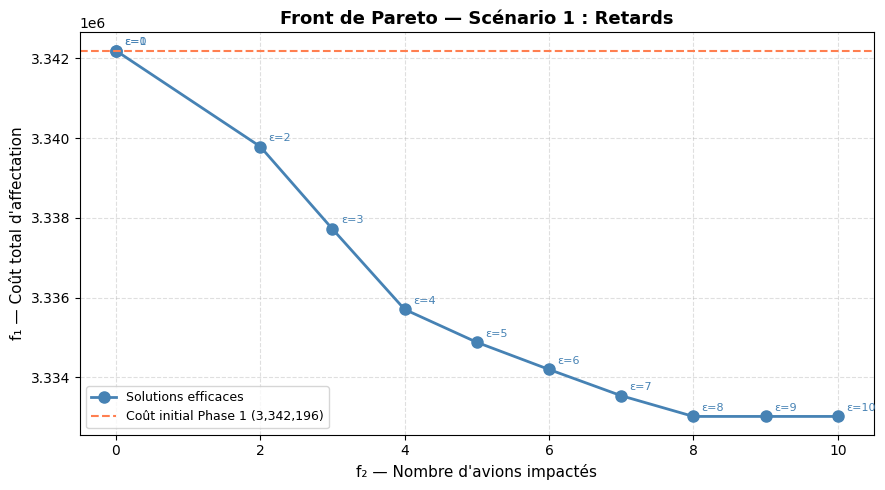

Front de Pareto sauvegardé : pareto_scénario_1_:_retards.png


In [16]:
plot_pareto(df_s1, scenario_name="Scénario 1 : Retards", cost_initial=cost_initial)

Meilleur ε faisable : 0


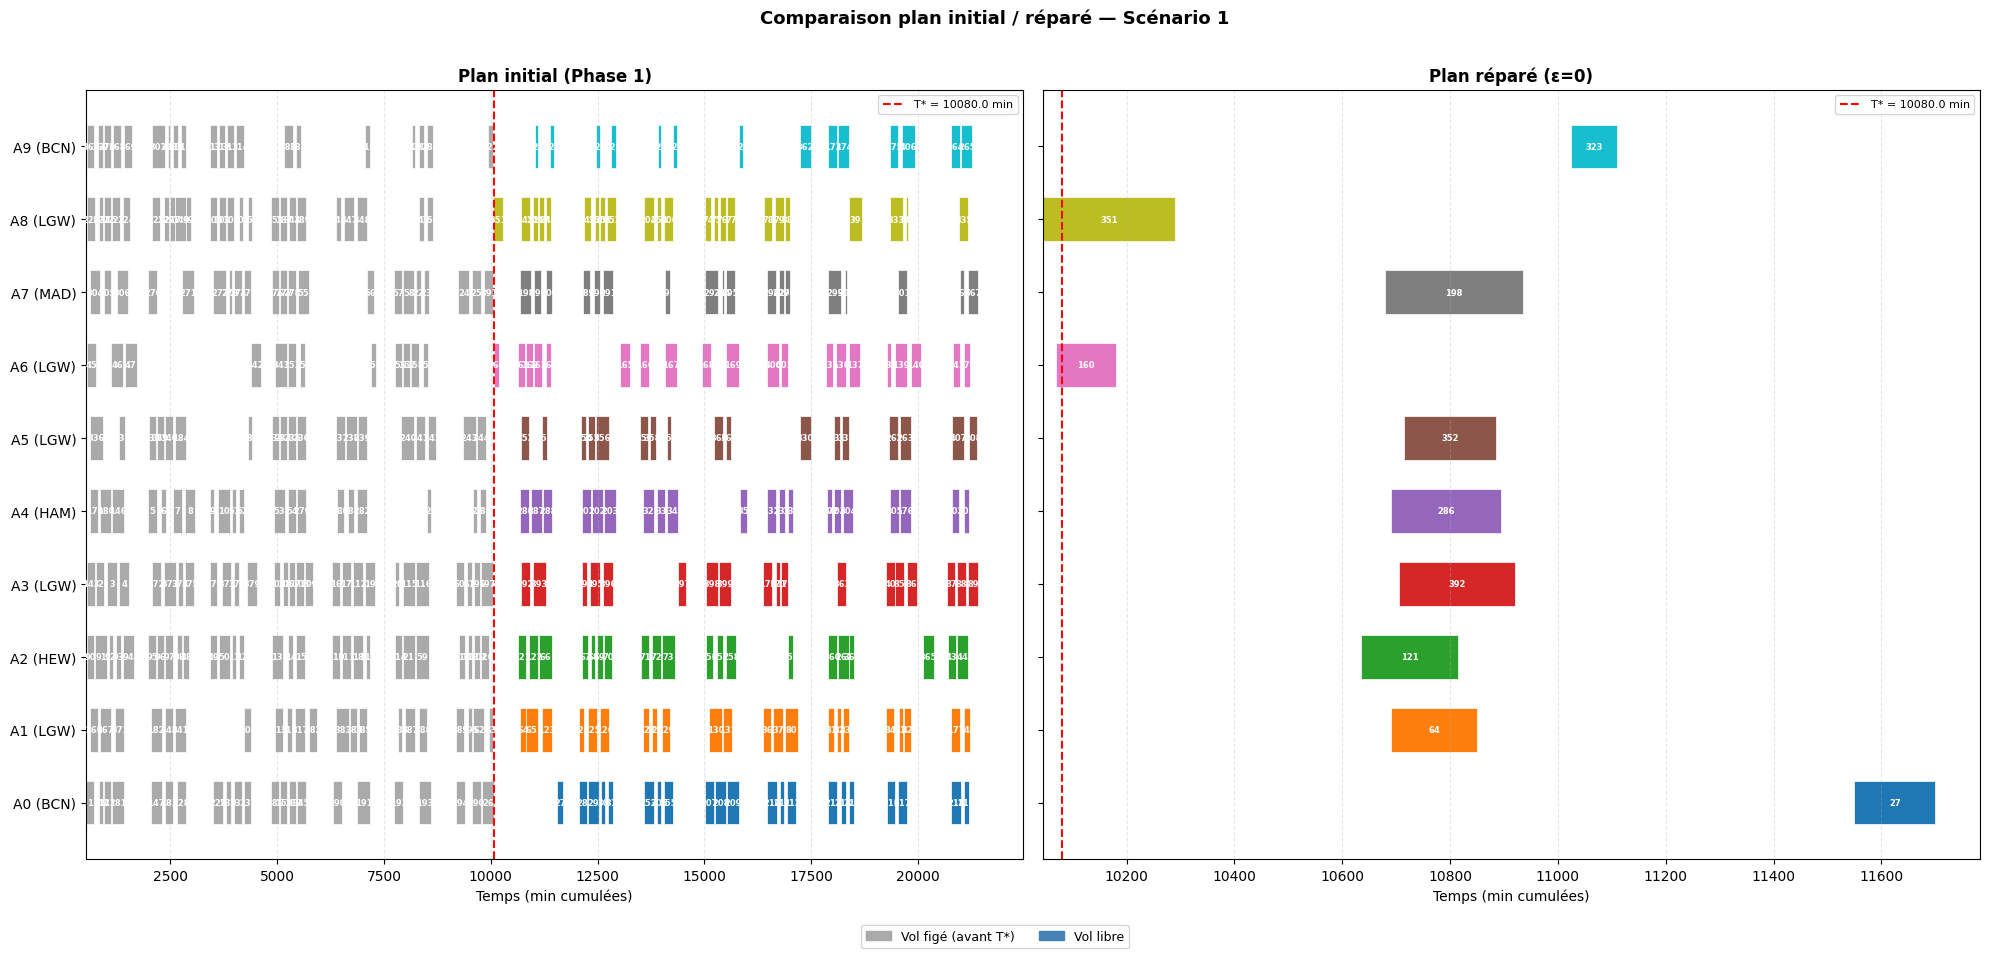

Gantt comparatif sauvegardé : gantt_repair_scénario_1_eps0.png


In [17]:
# ── Gantt comparatif pour la meilleure solution réparée ─────────────────────
# On choisit la solution avec le moins d'avions impactés parmi les feasible
best_eps_s1 = df_s1[df_s1["status"].isin(["OPTIMAL","FEASIBLE"])]["epsilon"].min()
print(f"Meilleur ε faisable : {best_eps_s1}")

plot_gantt_comparison(
    flights_s1, bases,
    rotations_initial,
    rots_s1[best_eps_s1],
    T_STAR_S1,
    scenario_name="Scénario 1",
    epsilon=best_eps_s1
)

---
## Scénario 2 — Interdiction d'atterrissage dans un aéroport

**Situation** : l'avion $a^*$ ne peut pas atterrir ni décoller de l'aéroport $p$
pendant la période $[T_1, T_2]$ (matériels de maintenance indisponibles).

In [18]:
# ─── Paramètres du Scénario 2 — recalibrés pour h=15 ────────────────────────
T_STAR_S2           = 10080.0   # horizon ~ jour 7
AIRCRAFT_FORBIDDEN  = 0         # avion A0 (base: BCN)
AIRPORT_FORBIDDEN   = "LGW"     # interdit atterrissage
T1_S2               = 10080.0   # début interdiction
T2_S2               = 14400.0   # fin interdiction (~jour 10)
# ─────────────────────────────────────────────────────────────────────────────

E_s2 = E  # horaires inchangés

print(f"Scénario 2 configuré")
print(f"  Horizon T*          : {T_STAR_S2} min  (~jour {T_STAR_S2/1440:.1f})")
print(f"  Avion interdit      : A{AIRCRAFT_FORBIDDEN} (base: {bases[AIRCRAFT_FORBIDDEN]})")
print(f"  Aéroport interdit   : {AIRPORT_FORBIDDEN}")
print(f"  Période             : [{T1_S2}, {T2_S2}] min")

vols_bloques = [
    f.fid for f in flights
    if (f.dest == AIRPORT_FORBIDDEN and T1_S2 <= f.arr <= T2_S2) or
       (f.origin == AIRPORT_FORBIDDEN and T1_S2 <= f.dep <= T2_S2)
]
print(f"  Vols bloqués pour A{AIRCRAFT_FORBIDDEN} : {len(vols_bloques)} vols → {vols_bloques[:10]}")


Scénario 2 configuré
  Horizon T*          : 10080.0 min  (~jour 7.0)
  Avion interdit      : A0 (base: BCN)
  Aéroport interdit   : LGW
  Période             : [10080.0, 14400.0] min
  Vols bloqués pour A0 : 23 vols → [33, 34, 125, 126, 165, 166, 167, 245, 246, 247]


In [19]:
# ── Résolution ε-contrainte — Scénario 2 ────────────────────────────────────
df_s2, rots_s2 = run_epsilon_constraint(
    flights, bases, cost, E_s2, x_star, T_STAR_S2,
    forbidden_aircraft_airport=(AIRCRAFT_FORBIDDEN, AIRPORT_FORBIDDEN, T1_S2, T2_S2),
    scenario_name="Scénario 2 : Interdiction aéroport"
)
df_s2


  ε-contrainte — Scénario 2 : Interdiction aéroport
  Horizon T* = 10080.0 min | Avions = 10
     ε       f1 (coût)   f2 (impactés)  statut      
  --------------------------------------------------
  ε=  0       3342196.0               0  OPTIMAL     
  ε=  1       3342196.0               0  OPTIMAL     
  ε=  2       3339790.0               2  OPTIMAL     
  ε=  3       3337723.0               3  OPTIMAL     
  ε=  4       3335707.0               4  OPTIMAL     
  ε=  5       3334882.0               5  OPTIMAL     
  ε=  6       3334201.0               6  OPTIMAL     
  ε=  7       3333543.0               7  OPTIMAL     
  ε=  8       3333023.0               8  OPTIMAL     
  ε=  9       3333023.0               9  OPTIMAL     
  ε= 10       3333023.0              10  OPTIMAL     


,epsilon,f1,f2,status
0,0,3342196.0,0,OPTIMAL
1,1,3342196.0,0,OPTIMAL
2,2,3339790.0,2,OPTIMAL
3,3,3337723.0,3,OPTIMAL
4,4,3335707.0,4,OPTIMAL
5,5,3334882.0,5,OPTIMAL
6,6,3334201.0,6,OPTIMAL
7,7,3333543.0,7,OPTIMAL
8,8,3333023.0,8,OPTIMAL
9,9,3333023.0,9,OPTIMAL


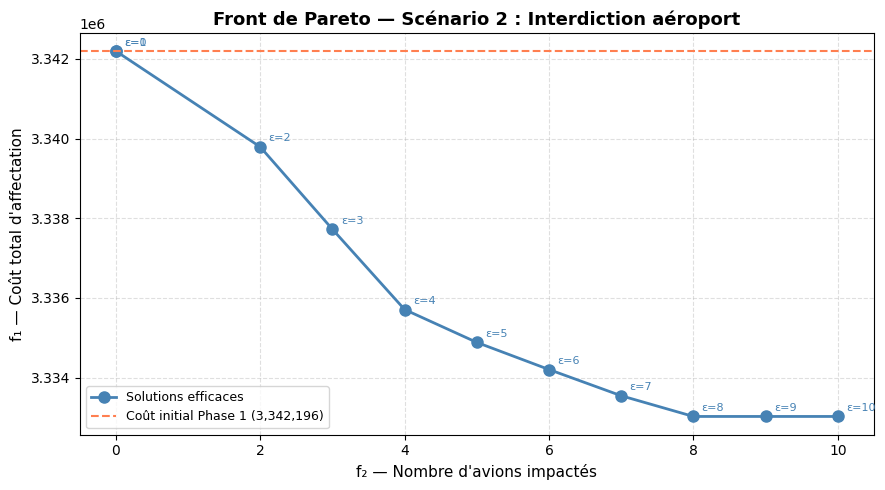

Front de Pareto sauvegardé : pareto_scénario_2_:_interdiction_aéroport.png


In [20]:
plot_pareto(df_s2, scenario_name="Scénario 2 : Interdiction aéroport", cost_initial=cost_initial)

Meilleur ε faisable : 0


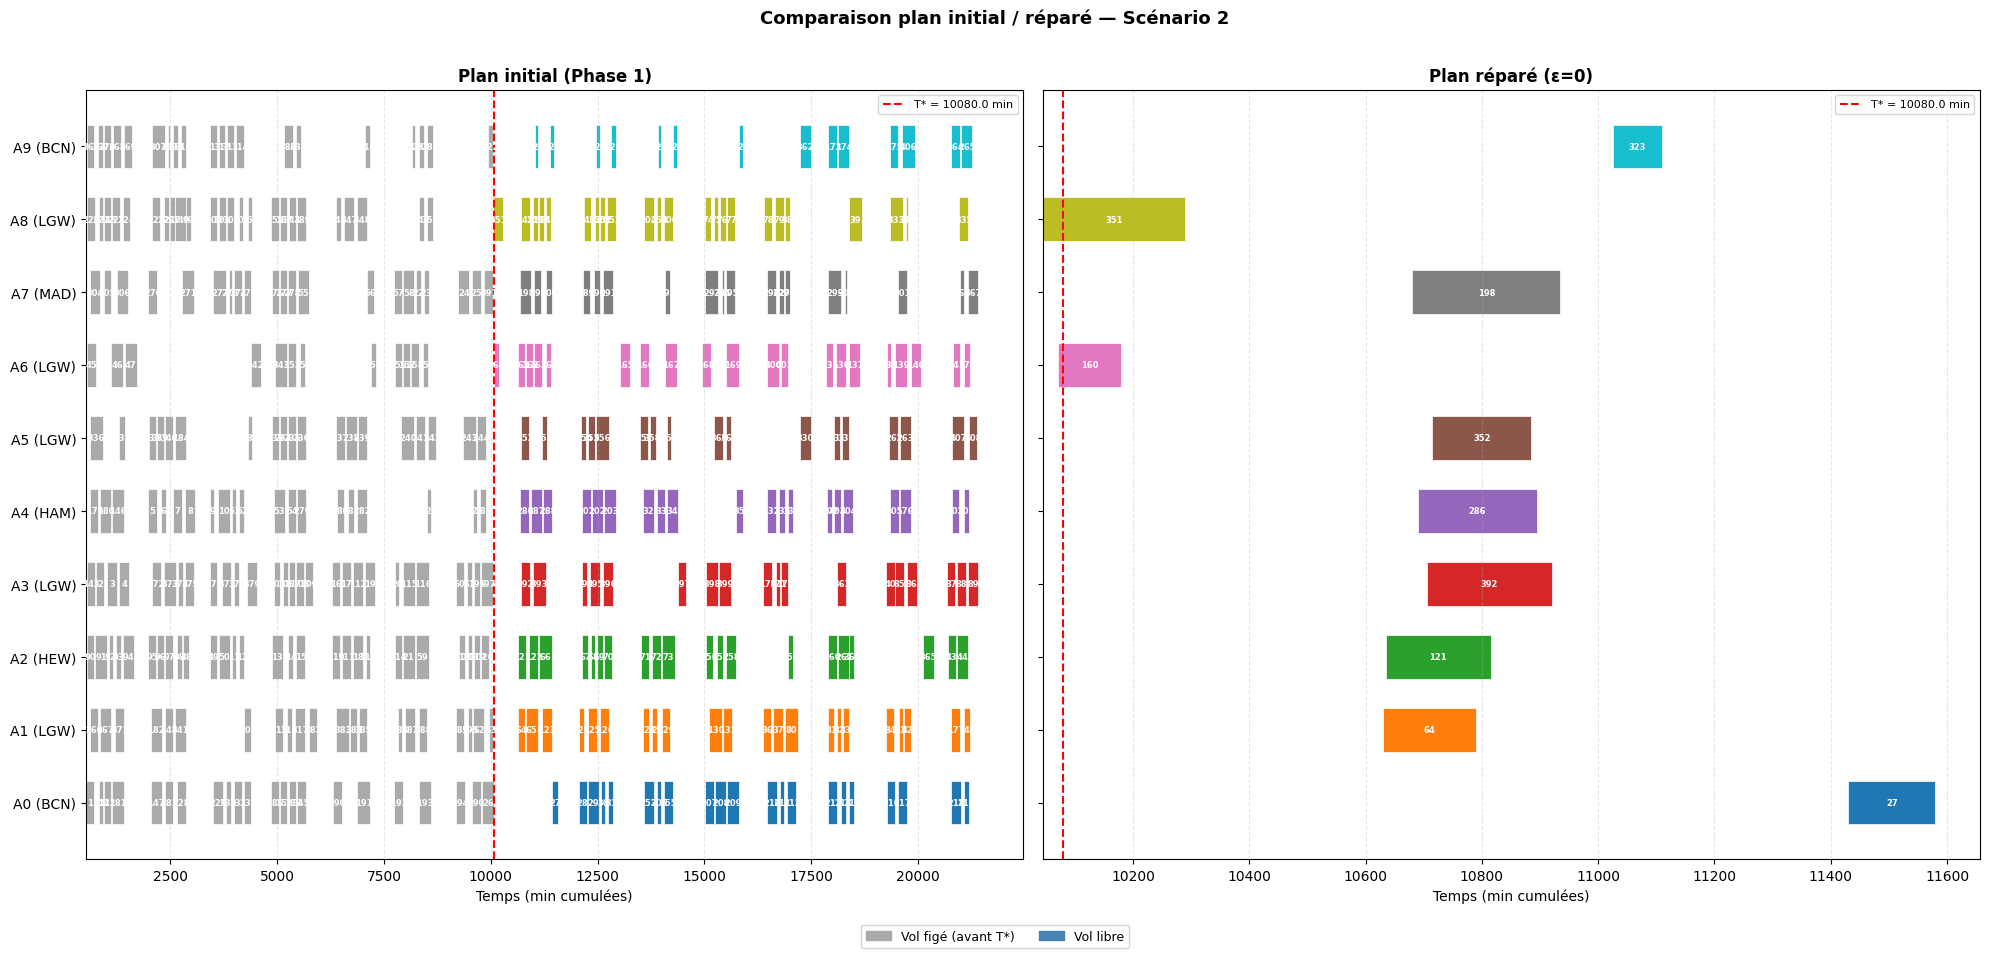

Gantt comparatif sauvegardé : gantt_repair_scénario_2_eps0.png


In [21]:
best_eps_s2 = df_s2[df_s2["status"].isin(["OPTIMAL","FEASIBLE"])]["epsilon"].min()
print(f"Meilleur ε faisable : {best_eps_s2}")

plot_gantt_comparison(
    flights, bases,
    rotations_initial,
    rots_s2[best_eps_s2],
    T_STAR_S2,
    scenario_name="Scénario 2",
    epsilon=best_eps_s2
)

---
## Scénario 3 — Annulation de vols (fermeture d'aéroport météo)

**Situation** : un aéroport est fermé pendant $[T_1, T_2]$.
Tous les vols à destination ou en provenance de cet aéroport pendant cette période
sont **annulés** — ils sont retirés du problème.

In [22]:
# ─── Paramètres du Scénario 3 — recalibrés pour h=15 ────────────────────────
T_STAR_S3      = 10080.0   # horizon ~ jour 7
AIRPORT_CLOSED = "LGW"     # aéroport fermé
T1_S3          = 10080.0   # début fermeture
T2_S3          = 12960.0   # fin fermeture (~jour 9)
# ─────────────────────────────────────────────────────────────────────────────

fids_cancelled = {
    f.fid for f in flights
    if ((f.dest == AIRPORT_CLOSED and T1_S3 <= f.arr <= T2_S3) or
        (f.origin == AIRPORT_CLOSED and T1_S3 <= f.dep <= T2_S3))
    and f.dep >= T_STAR_S3
}

E_s3 = {(i, j) for (i, j) in E
        if i not in fids_cancelled and j not in fids_cancelled}

print(f"Scénario 3 configuré")
print(f"  Horizon T*          : {T_STAR_S3} min  (~jour {T_STAR_S3/1440:.1f})")
print(f"  Aéroport fermé      : {AIRPORT_CLOSED}")
print(f"  Période fermeture   : [{T1_S3}, {T2_S3}] min  ({(T2_S3-T1_S3)/1440:.1f} jours)")
print(f"  Vols annulés        : {len(fids_cancelled)} vols → {sorted(fids_cancelled)[:10]}")
print(f"  Arcs graphe modifié : {len(E_s3)}  (vs {len(E)} initial)")


Scénario 3 configuré
  Horizon T*          : 10080.0 min  (~jour 7.0)
  Aéroport fermé      : LGW
  Période fermeture   : [10080.0, 12960.0] min  (2.0 jours)
  Vols annulés        : 17 vols → [125, 126, 245, 246, 247, 248, 249, 250, 251, 252]
  Arcs graphe modifié : 8182  (vs 9017 initial)


In [23]:
# ── Résolution ε-contrainte — Scénario 3 ────────────────────────────────────
df_s3, rots_s3 = run_epsilon_constraint(
    flights, bases, cost, E_s3, x_star, T_STAR_S3,
    forbidden_fids=fids_cancelled,
    scenario_name="Scénario 3 : Annulations"
)
df_s3


  ε-contrainte — Scénario 3 : Annulations
  Horizon T* = 10080.0 min | Avions = 10
     ε       f1 (coût)   f2 (impactés)  statut      
  --------------------------------------------------
  ε=  0       3212160.0               0  OPTIMAL     
  ε=  1       3212160.0               0  OPTIMAL     
  ε=  2       3210003.0               2  OPTIMAL     
  ε=  3       3208032.0               3  OPTIMAL     
  ε=  4       3206079.0               4  OPTIMAL     
  ε=  5       3205254.0               5  OPTIMAL     
  ε=  6       3204573.0               6  OPTIMAL     
  ε=  7       3204053.0               7  OPTIMAL     
  ε=  8       3203557.0               8  OPTIMAL     
  ε=  9       3203557.0               9  OPTIMAL     
  ε= 10       3203557.0              10  OPTIMAL     


,epsilon,f1,f2,status
0,0,3212160.0,0,OPTIMAL
1,1,3212160.0,0,OPTIMAL
2,2,3210003.0,2,OPTIMAL
3,3,3208032.0,3,OPTIMAL
4,4,3206079.0,4,OPTIMAL
5,5,3205254.0,5,OPTIMAL
6,6,3204573.0,6,OPTIMAL
7,7,3204053.0,7,OPTIMAL
8,8,3203557.0,8,OPTIMAL
9,9,3203557.0,9,OPTIMAL


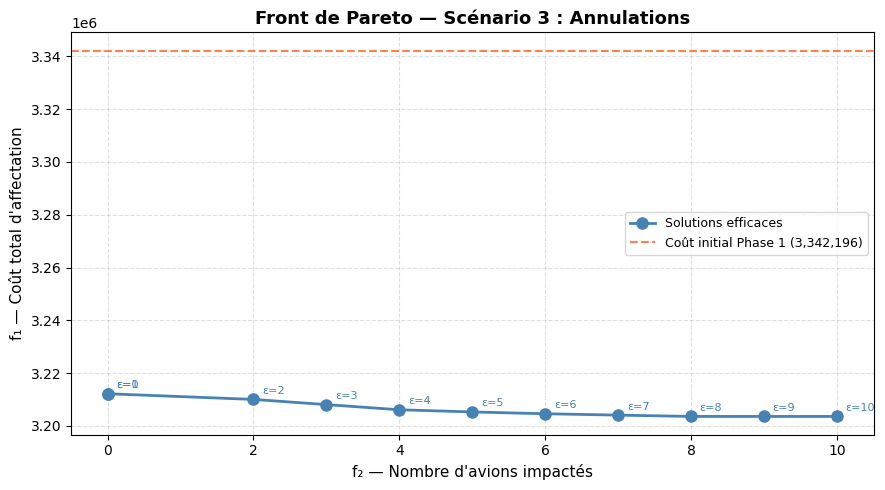

Front de Pareto sauvegardé : pareto_scénario_3_:_annulations.png


In [24]:
plot_pareto(df_s3, scenario_name="Scénario 3 : Annulations", cost_initial=cost_initial)

Meilleur ε faisable : 0


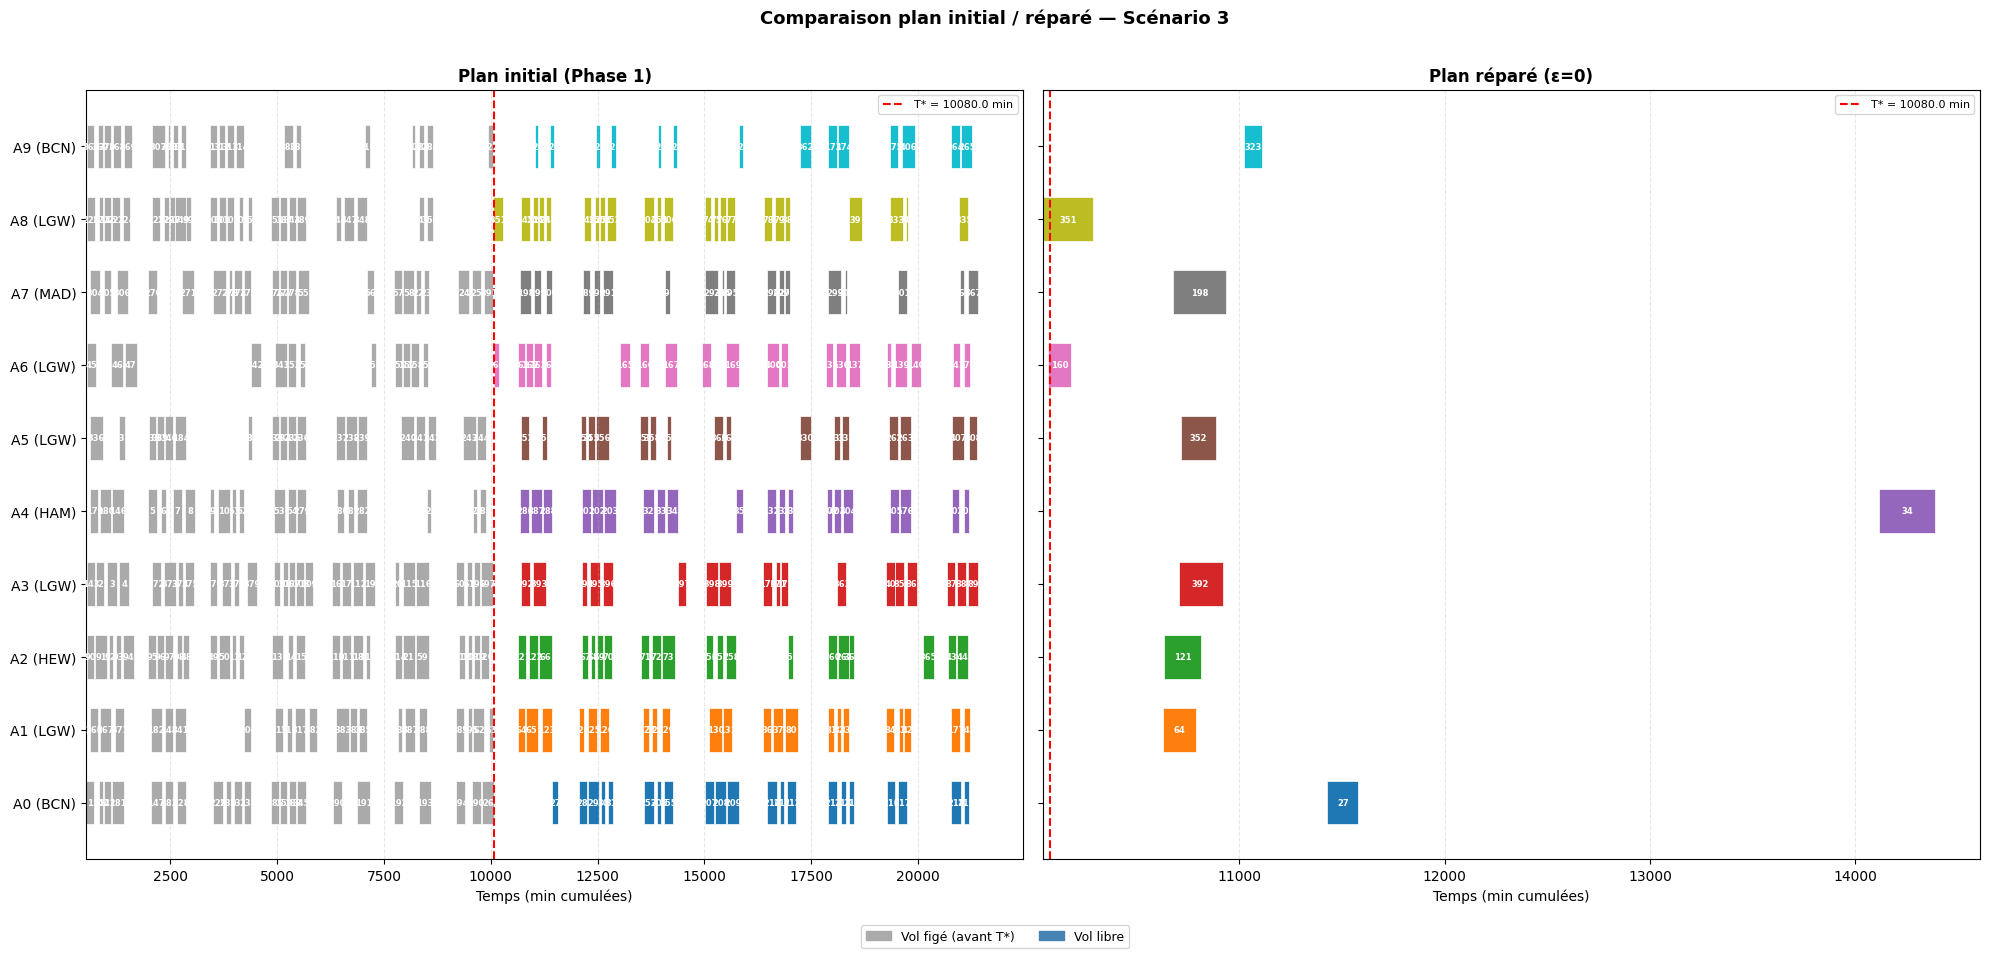

Gantt comparatif sauvegardé : gantt_repair_scénario_3_eps0.png


In [25]:
best_eps_s3 = df_s3[df_s3["status"].isin(["OPTIMAL","FEASIBLE"])]["epsilon"].min()
print(f"Meilleur ε faisable : {best_eps_s3}")

plot_gantt_comparison(
    flights, bases,
    rotations_initial,
    rots_s3[best_eps_s3],
    T_STAR_S3,
    scenario_name="Scénario 3",
    epsilon=best_eps_s3
)

---
## 6. Comparaison des 3 scénarios

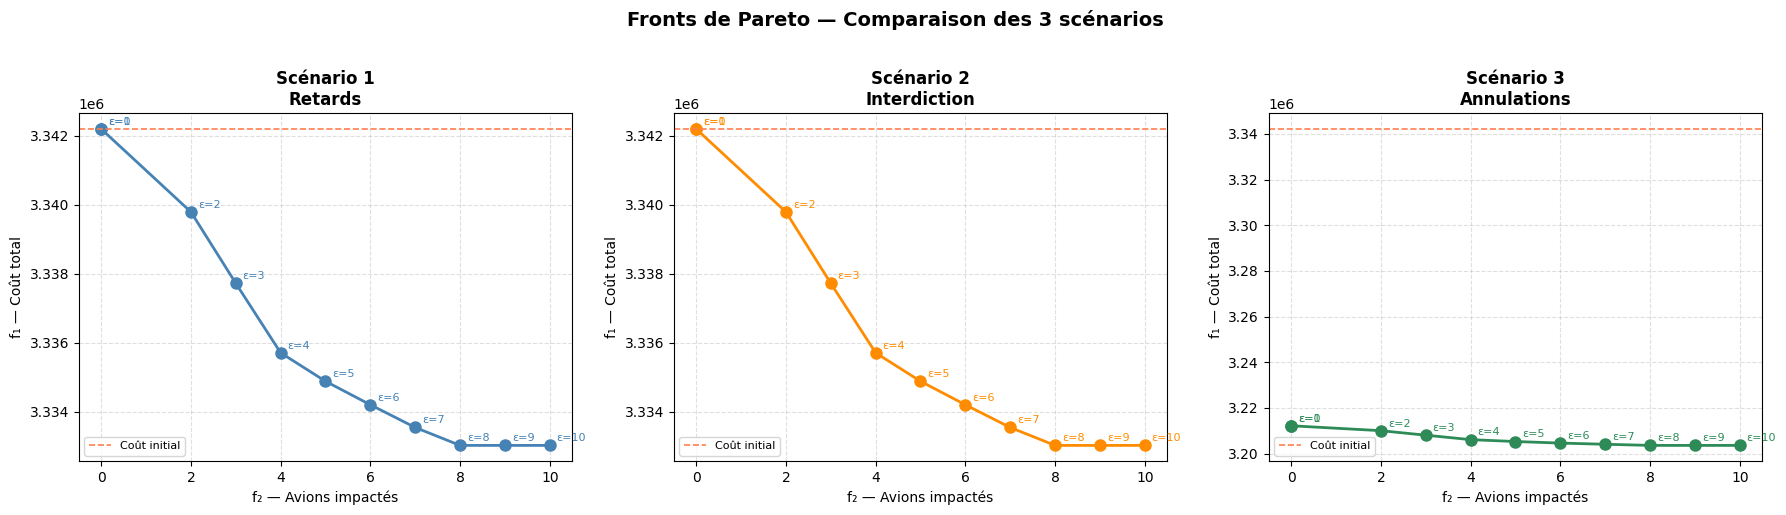

Comparaison sauvegardée : pareto_comparaison.png


In [26]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=False)

scenarios = [
    (df_s1, "Scénario 1\nRetards",     "steelblue"),
    (df_s2, "Scénario 2\nInterdiction","darkorange"),
    (df_s3, "Scénario 3\nAnnulations", "seagreen"),
]

for ax, (df, title, color) in zip(axes, scenarios):
    df_ok = df[df["status"].isin(["OPTIMAL", "FEASIBLE"])]
    ax.plot(df_ok["f2"], df_ok["f1"], "o-", color=color, linewidth=2, markersize=8)
    for _, row in df_ok.iterrows():
        ax.annotate(f"ε={int(row['epsilon'])}",
                    xy=(row['f2'], row['f1']),
                    xytext=(5, 3), textcoords="offset points",
                    fontsize=8, color=color)
    if cost_initial is not None:
        ax.axhline(cost_initial, color="coral", linestyle="--",
                   linewidth=1.2, label="Coût initial")
    ax.set_xlabel("f₂ — Avions impactés")
    ax.set_ylabel("f₁ — Coût total")
    ax.set_title(title, fontweight="bold")
    ax.legend(fontsize=8)
    ax.grid(True, linestyle="--", alpha=0.4)
    ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))

plt.suptitle("Fronts de Pareto — Comparaison des 3 scénarios",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("pareto_comparaison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Comparaison sauvegardée : pareto_comparaison.png")

In [27]:
# ── Tableau récapitulatif des meilleures solutions réparées ──────────────────

def best_solution_row(df, scenario):
    df_ok = df[df["status"].isin(["OPTIMAL", "FEASIBLE"])]
    if df_ok.empty:
        return {"scénario": scenario, "ε_min_faisable": None,
                "f1 (coût)": None, "f2 (impactés)": None,
                "Δ coût vs initial": None}
    best = df_ok.loc[df_ok["epsilon"].idxmin()]
    return {
        "scénario"          : scenario,
        "ε_min_faisable"    : int(best["epsilon"]),
        "f1 (coût)"         : f"{best['f1']:,.1f}" if best["f1"] else "-",
        "f2 (impactés)"     : int(best["f2"]) if best["f2"] is not None else "-",
        "Δ coût vs initial" : f"+{best['f1']-cost_initial:,.1f}" if best["f1"] and cost_initial else "-"
    }

summary = pd.DataFrame([
    {"scénario": "Phase 1 (initial)", "ε_min_faisable": "-",
     "f1 (coût)": f"{cost_initial:,.1f}", "f2 (impactés)": 0, "Δ coût vs initial": "—"},
    best_solution_row(df_s1, "Scénario 1 : Retards"),
    best_solution_row(df_s2, "Scénario 2 : Interdiction aéroport"),
    best_solution_row(df_s3, "Scénario 3 : Annulations"),
]).set_index("scénario")

print("Récapitulatif des meilleures solutions réparées :")
summary

Récapitulatif des meilleures solutions réparées :


,ε_min_faisable,f1 (coût),f2 (impactés),Δ coût vs initial
scénario,,,,
Phase 1 (initial),-,"3,342,196.0",0,—
Scénario 1 : Retards,0,"3,342,196.0",0,+0.0
Scénario 2 : Interdiction aéroport,0,"3,342,196.0",0,+0.0
Scénario 3 : Annulations,0,"3,212,160.0",0,"+-130,036.0"
